# Explore road data

In [35]:
import numpy as np
import pandas as pd

import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

import rasterio
from rasterio.merge import merge
from rasterio.mask import mask

import osmnx as ox

In [36]:
road_data_path = Path("../data/output/processed_roads_official/merged_osm_heigit_liu.gpkg")
roads_gdf = gpd.read_file(road_data_path)

roads_gdf.head()

c:\Users\Move\anaconda3\envs\gds24\lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Non-conformant content for record 207452 in column osm_changeset_timestamp, 2023-09-01T21:14:24+02:00, successfully parsed
  return ogr_read(


,ID,Start_pt,End_pt,Rd_length,Surface,data_src,continent,country_iso_a2,country_iso_a3,urban,...,lanes,oneway,bridge,layer,source,name:fr,name_en,name_fr,path,geometry
0,1.0,"(1103991.702615, 328198.947937)","(1103520.286835, 328787.695206)",762.730176,paved,liu,None,None,None,NaN,...,None,None,None,None,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1103991.703 328198.948, 1103..."
1,2.0,"(1103520.286835, 328787.695206)","(1103479.510506, 327812.637704)",980.028403,paved,liu,None,None,None,NaN,...,None,None,None,None,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1103520.287 328787.695, 1103..."
2,3.0,"(1094496.606460, 264352.420784)","(1094836.587317, 264478.208504)",364.363710,paved,liu,None,None,None,NaN,...,None,None,None,None,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1094496.606 264352.421, 1094..."
3,4.0,"(1102316.032584, 283330.554237)","(1101453.228606, 267250.567070)",23257.130654,unpaved,liu,None,None,None,NaN,...,None,None,None,None,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1102316.033 283330.554, 1102..."
4,5.0,"(1103057.420392, 327326.354672)","(1102985.552529, 327212.146541)",134.938827,paved,liu,None,None,None,NaN,...,None,None,None,None,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1103057.42 327326.355, 11029..."


In [37]:
roads_gdf.shape

(855743, 38)

In [38]:
roads_gdf.data_src.value_counts()

data_src
heigit    355143
osm       293149
liu       207451
Name: count, dtype: int64

In [39]:
# check duplicates
roads_gdf.duplicated(subset=["geometry"]).sum()

69644

Duplicate rows (including both/all occurrences): 133800
Duplicate geometries (unique): 64156


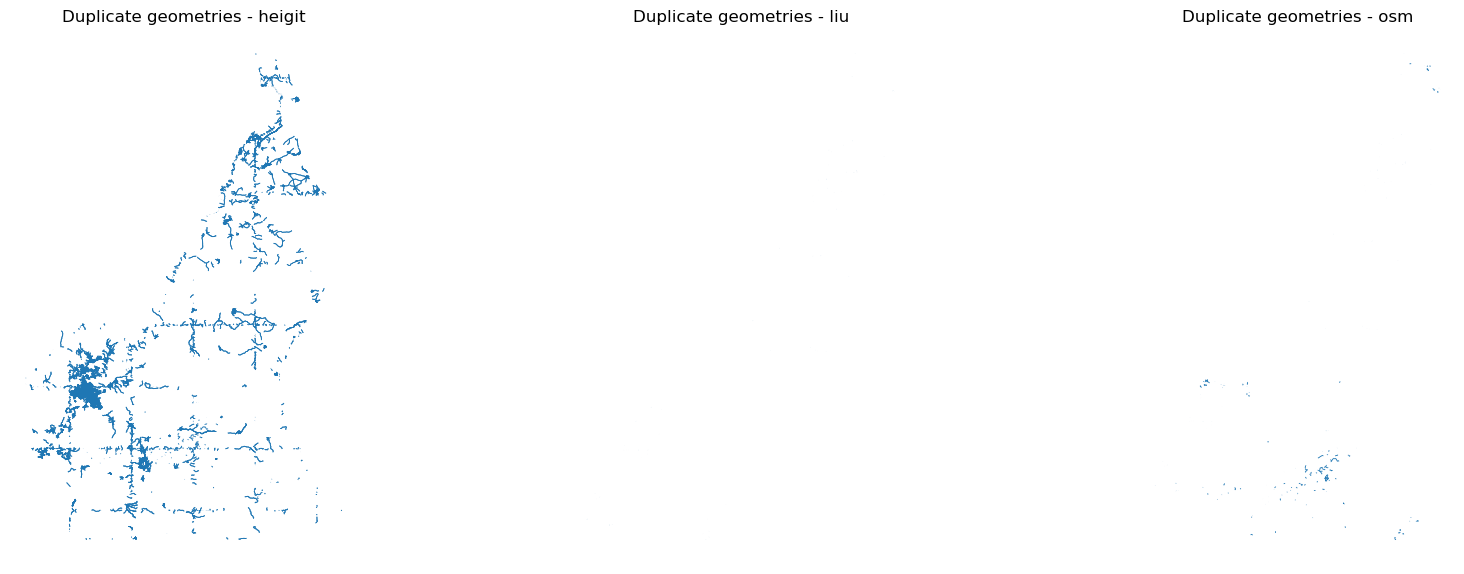

In [40]:
# Select all rows involved in duplicate geometries
dup_mask = roads_gdf.duplicated(subset=["geometry"], keep=False) # keep=False marks all duplicates as True, not just the first occurrence
duplicates_gdf = roads_gdf.loc[dup_mask].copy()

print(f"Duplicate rows (including both/all occurrences): {len(duplicates_gdf)}")
print(f"Duplicate geometries (unique): {duplicates_gdf['geometry'].nunique()}")

# Plot 3 separate maps by data source
if duplicates_gdf.empty:
    print("No duplicate geometries found.")
else:
    sources = sorted(duplicates_gdf["data_src"].dropna().unique())[:3]
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, ax in enumerate(axes):
        if i < len(sources):
            src = sources[i]
            duplicates_gdf.loc[duplicates_gdf["data_src"] == src].plot(
                ax=ax, linewidth=0.6
            )
            ax.set_title(f"Duplicate geometries - {src}")
        else:
            ax.set_title("No data")
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()

In [41]:
duplicates_gdf.data_src.value_counts()

data_src
heigit    133435
osm          300
liu           65
Name: count, dtype: int64

In [42]:
dup_counts = duplicates_gdf["geometry"].value_counts()
num_duplicate_pairs = (dup_counts // 2).sum()

print(f"Number of duplicate pairs: {num_duplicate_pairs}")

Number of duplicate pairs: 66448


In [43]:
dup_counts

geometry
MULTILINESTRING ((1548646.254 1254030.073, 154...    36
MULTILINESTRING ((1574924.222 1260204.201, 157...    20
MULTILINESTRING ((1145146.719 625825.402, 1145...    16
MULTILINESTRING ((1092958.806 445767.547, 1093...    16
MULTILINESTRING ((1192410.637 625644.42, 11924...    16
                                                     ..
MULTILINESTRING ((1140956.208 672303.797, 1141...     2
MULTILINESTRING ((1139578.406 671890.857, 1139...     2
MULTILINESTRING ((1139628.946 672244.805, 1139...     2
MULTILINESTRING ((1139588.871 672118.315, 1139...     2
MULTILINESTRING ((1154458.294 694190.637, 1154...     2
Name: count, Length: 64156, dtype: int64

In [44]:
# create a new GeoDataFrame by dropping duplicates based on geometry, keeping the first occurrence
roads_gdf_dedup = roads_gdf.drop_duplicates(subset=["geometry"], keep="first").copy()
print(f"Number of rows after deduplication: {len(roads_gdf_dedup)}")

Number of rows after deduplication: 786099


In [45]:
# Deduplicate by osm_id only for non-liu rows
liu_mask = roads_gdf_dedup["data_src"].eq("liu")
non_liu = roads_gdf_dedup.loc[~liu_mask]
non_liu_dedup = pd.concat(
    [
        non_liu.loc[non_liu["osm_id"].isna()],  # keep rows without osm_id
        non_liu.loc[non_liu["osm_id"].notna()].drop_duplicates(subset=["osm_id"], keep="first"),
    ]
)

roads_gdf_dedup = pd.concat([roads_gdf_dedup.loc[liu_mask], non_liu_dedup]).sort_index().copy()
print(f"Number of rows after deduplication: {len(roads_gdf_dedup)}")

Number of rows after deduplication: 533153


In [46]:
roads_gdf_dedup.data_src.value_counts()

data_src
heigit    285769
liu       207451
osm        39933
Name: count, dtype: int64

In [47]:
# Map OSM/HEIGIT roads to paved/unpaved using highway class.
# Liu roads already have a reliable surface label from the dataset.
# Previously all non-Liu roads were hardcoded as "unpaved" — this incorrectly
# labelled primary, secondary, trunk roads as unpaved in the friction raster.
# Rows with unmappable highway values (e.g. "unknown", "Piste") get NaN
# and will be excluded by the filter in the friction construction script.
highway_to_surface = {
    "motorway":       "paved",
    "motorway_link":  "paved",
    "trunk":          "paved",
    "trunk_link":     "paved",
    "primary":        "paved",
    "primary_link":   "paved",
    "secondary":      "paved",
    "secondary_link": "paved",
    "tertiary":       "paved",
    "tertiary_link":  "paved",
    "residential":    "unpaved",
    "unclassified":   "unpaved",
    "living_street":  "unpaved",
    "service":        "unpaved",
    "track":          "unpaved",
    "path":           "unpaved",
    "footway":        "unpaved",
    "bridleway":      "unpaved",
    "steps":          "unpaved",
    "pedestrian":     "unpaved",
    "road":           "unpaved",
    "construction":   "unpaved",
}

roads_gdf_dedup["liu_surface"] = np.where(
    roads_gdf_dedup["data_src"] == "liu",
    roads_gdf_dedup["Surface"],                          # Liu: use their paved/unpaved label
    roads_gdf_dedup["highway"].map(highway_to_surface),  # OSM/HEIGIT: derive from highway class
)

print(roads_gdf_dedup["liu_surface"].value_counts(dropna=False))

liu_surface
unpaved    497873
paved       35248
NaN            32
Name: count, dtype: int64


In [48]:
# remove any vectors that are overlapping in terms of location with the 'liu' data source
liu_gdf = roads_gdf_dedup.loc[roads_gdf_dedup["data_src"] == "liu"].copy()
non_liu_gdf = roads_gdf_dedup.loc[roads_gdf_dedup["data_src"] != "liu"].copy()

# Ensure both GeoDataFrames use the same CRS
liu_gdf = liu_gdf.to_crs(non_liu_gdf.crs)

# Add an index to liu_gdf for identification
liu_gdf = liu_gdf.reset_index(drop=True)
liu_gdf["liu_idx"] = liu_gdf.index

# Perform a spatial join: find non_liu_gdf rows that intersect any liu_gdf row
joined = gpd.sjoin(non_liu_gdf, liu_gdf[["geometry", "liu_idx"]], how="left", predicate="intersects")

# Rows with a match in liu_gdf will have a non-null 'liu_idx'
non_liu_no_overlap = joined[joined["liu_idx"].isna()].drop(columns=["liu_idx", "index_right"])

# Concatenate liu_gdf and the filtered non_liu_gdf
temp_gdf = pd.concat([liu_gdf, non_liu_no_overlap]).sort_index().copy()
print(f"Number of rows after removing overlaps: {len(temp_gdf)}")
temp_gdf.data_src.value_counts()

Number of rows after removing overlaps: 304351


data_src
liu       207451
heigit     76222
osm        20678
Name: count, dtype: int64

In [49]:
# for temp_gdf; perform spatial join between data_src == 'osm' ans data_src == 'heigit' to check for any remaining overlaps
osm_gdf = temp_gdf.loc[temp_gdf["data_src"].eq("osm")].copy()
heigit_gdf = temp_gdf.loc[temp_gdf["data_src"].eq("heigit")].copy()

if osm_gdf.crs != heigit_gdf.crs:
    heigit_gdf = heigit_gdf.to_crs(osm_gdf.crs)

heigit_lookup = heigit_gdf[["geometry"]].copy()
heigit_lookup["heigit_idx"] = heigit_lookup.index

osm_heigit_overlaps = gpd.sjoin(
    osm_gdf,
    heigit_lookup,
    how="inner",
    predicate="intersects",
)

print(f"OSM rows overlapping HEIGIT rows: {osm_heigit_overlaps.index.nunique()}")
print(f"HEIGIT rows overlapped by OSM: {osm_heigit_overlaps['heigit_idx'].nunique()}")

osm_overlap_gdf = osm_gdf.loc[osm_heigit_overlaps.index.unique()].copy()
heigit_overlap_gdf = heigit_gdf.loc[osm_heigit_overlaps["heigit_idx"].unique()].copy()

print(osm_heigit_overlaps.shape)
osm_heigit_overlaps.head()


OSM rows overlapping HEIGIT rows: 12262
HEIGIT rows overlapped by OSM: 12507
(20219, 42)


,ID,Start_pt,End_pt,Rd_length,Surface,data_src,continent,country_iso_a2,country_iso_a3,urban,...,source,name:fr,name_en,name_fr,path,geometry,liu_surface,liu_idx,index_right,heigit_idx
562605,NaN,None,None,NaN,None,osm,None,None,None,NaN,...,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1417587.091 426791.974, 1417...",unpaved,NaN,529467,529467
562606,NaN,None,None,NaN,None,osm,None,None,None,NaN,...,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1417554.841 426808.542, 1417...",unpaved,NaN,529468,529468
562609,NaN,None,None,NaN,unpaved,osm,None,None,None,NaN,...,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1291593.81 437127.681, 12916...",unpaved,NaN,533446,533446
562620,NaN,None,None,NaN,None,osm,None,None,None,NaN,...,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1428520.579 415904.323, 1428...",unpaved,NaN,529431,529431
562621,NaN,None,None,NaN,None,osm,None,None,None,NaN,...,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1428708.676 415966.426, 1428...",unpaved,NaN,529432,529432


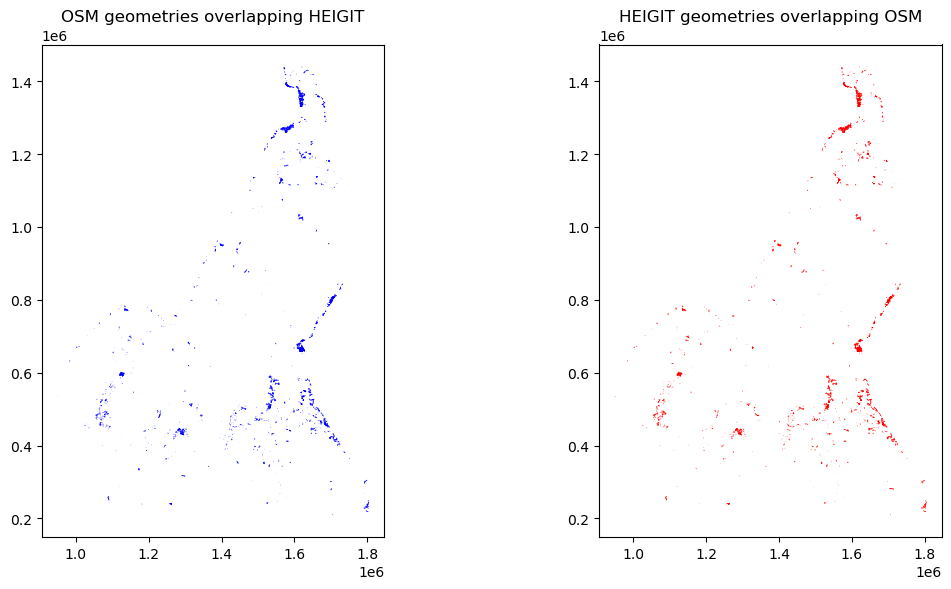

In [50]:
# plot the overlapping OSM and HEIGIT geometries to visually inspect the overlaps
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
osm_overlap_gdf.plot(ax=axes[0], color="blue", linewidth=0.6)
axes[0].set_title("OSM geometries overlapping HEIGIT")
heigit_overlap_gdf.plot(ax=axes[1], color="red", linewidth=0.6)
axes[1].set_title("HEIGIT geometries overlapping OSM")
plt.tight_layout()
plt.show()

In [51]:
# clean temp_gdf by removing the overlapping OSM and HEIGIT geometries
# keeping the liu geometries and non-overlapping OSM and HEIGIT geometries
# prioritize keeping OSM geometries over HEIGIT geometries in cases of overlap, since OSM is the fundamental map
temp_gdf = temp_gdf[~temp_gdf.index.isin(osm_overlap_gdf.index)]

In [52]:
temp_gdf

,ID,Start_pt,End_pt,Rd_length,Surface,data_src,continent,country_iso_a2,country_iso_a3,urban,...,bridge,layer,source,name:fr,name_en,name_fr,path,geometry,liu_surface,liu_idx
0,1.0,"(1103991.702615, 328198.947937)","(1103520.286835, 328787.695206)",762.730176,paved,liu,None,None,None,NaN,...,None,None,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1103991.703 328198.948, 1103...",paved,0.0
1,2.0,"(1103520.286835, 328787.695206)","(1103479.510506, 327812.637704)",980.028403,paved,liu,None,None,None,NaN,...,None,None,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1103520.287 328787.695, 1103...",paved,1.0
2,3.0,"(1094496.606460, 264352.420784)","(1094836.587317, 264478.208504)",364.363710,paved,liu,None,None,None,NaN,...,None,None,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1094496.606 264352.421, 1094...",paved,2.0
3,4.0,"(1102316.032584, 283330.554237)","(1101453.228606, 267250.567070)",23257.130654,unpaved,liu,None,None,None,NaN,...,None,None,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1102316.033 283330.554, 1102...",unpaved,3.0
4,5.0,"(1103057.420392, 327326.354672)","(1102985.552529, 327212.146541)",134.938827,paved,liu,None,None,None,NaN,...,None,None,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1103057.42 327326.355, 11029...",paved,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
855609,NaN,None,None,NaN,None,osm,None,None,None,NaN,...,None,None,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1292495.742 429558.263, 1292...",unpaved,NaN
855615,NaN,None,None,NaN,paved,osm,None,None,None,NaN,...,yes,1,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1109183.031 559722.972, 1109...",paved,NaN
855623,NaN,None,None,NaN,None,osm,None,None,None,NaN,...,None,None,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1719005.184 842899.343, 1719...",unpaved,NaN
855630,NaN,None,None,NaN,asphalt,osm,None,None,None,NaN,...,yes,1,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1108408.671 559396.679, 1108...",paved,NaN


In [53]:
temp_gdf["liu_surface"].value_counts()

liu_surface
unpaved    270152
paved       21919
Name: count, dtype: int64

In [54]:
temp_gdf.data_src.value_counts()

data_src
liu       207451
heigit     76222
osm         8416
Name: count, dtype: int64

In [55]:
final_gdf = temp_gdf.copy()

# save gdf

In [ ]:
# save the deduplicated GeoDataFrame to a new file
final_path = Path("../data/output/processed_roads_official/cleaned_merged_osm_heigit_liu-ver3-midterm.gpkg")
final_gdf.to_file(final_path, driver="GPKG")

# load cleaned roads

In [ ]:
# load the saved file to verify
filepath = Path("../data/output/processed_roads_official/cleaned_merged_osm_heigit_liu-ver3.gpkg")
loaded_gdf = gpd.read_file(filepath)
loaded_gdf.head()

# Analyze cleaned road network

## Road length validation

In [ ]:
# calculate the total length of roads in the final GeoDataFrame
gdf = loaded_gdf.to_crs(32632)  # example projected CRS in meters; pick one suitable for your area

# length of each road segment (meters)
gdf["length_m"] = gdf.geometry.length

# total length in km
total_km = gdf["length_m"].sum() / 1000
print(total_km)

203136.98256241603


In [ ]:
# calculate total length of paved vs unpaved roads
paved_length_km = gdf.loc[gdf["liu_surface"] == "paved", "length_m"].sum() / 1000
unpaved_length_km = gdf.loc[gdf["liu_surface"] == "unpaved", "length_m"].sum() / 1000
print(f"Paved roads: {paved_length_km:.2f} km")
print(f"Unpaved roads: {unpaved_length_km:.2f} km")

Paved roads: 17920.23 km
Unpaved roads: 185211.32 km


In [ ]:
print(f"Percentage of paved roads: {(paved_length_km/total_km)*100:.2f}%")
print(f"Percentage of unpaved roads: {(unpaved_length_km/total_km)*100:.2f}%")

Percentage of paved roads: 8.82%
Percentage of unpaved roads: 91.18%


In [ ]:
from pyproj import Geod

# WGS84 ellipsoid
geod = Geod(ellps="WGS84")

def geodesic_length(geom):
    # Only compute for LineString or MultiLineString
    if geom.is_empty:
        return 0
    if geom.geom_type == "LineString":
        return geod.geometry_length(geom)
    elif geom.geom_type == "MultiLineString":
        return sum(geod.geometry_length(part) for part in geom.geoms)
    else:
        return 0

gdf_wgs84 = loaded_gdf.to_crs(4326)
gdf_wgs84["length_m_geodesic"] = gdf_wgs84.geometry.apply(geodesic_length)
total_km_geodesic = gdf_wgs84["length_m_geodesic"].sum() / 1000
print(f"Total geodesic road length: {total_km_geodesic:.2f} km")

Total geodesic road length: 202741.06 km


In [ ]:
# do geodesic for paved vs unpaved
paved_length_km_geodesic = gdf_wgs84.loc[gdf_wgs84["liu_surface"] == "paved", "length_m_geodesic"].sum() / 1000
unpaved_length_km_geodesic = gdf_wgs84.loc[gdf_wgs84["liu_surface"] == "unpaved", "length_m_geodesic"].sum() / 1000
print(f"Paved roads (geodesic): {paved_length_km_geodesic:.2f} km")
print(f"Paved percentage (geodesic): {(paved_length_km_geodesic/total_km_geodesic)*100:.2f}%")
print(f"Unpaved roads (geodesic): {unpaved_length_km_geodesic:.2f} km")

Paved roads (geodesic): 17891.32 km
Paved percentage (geodesic): 8.82%
Unpaved roads (geodesic): 184844.33 km


In [ ]:
paved_length_km_geodesic + unpaved_length_km_geodesic

202735.65163026453

## Check class correlation: 'highway' -- 'liu_surface'

In [ ]:
# for all blank 'highway' values, fill in the 'highway' value 'unknown'
loaded_gdf["highway"] = loaded_gdf["highway"].fillna("unknown")

In [ ]:
loaded_gdf['highway'].value_counts()

highway
unknown           207451
path               36247
residential        28034
track              10391
unclassified        5232
service             1484
footway              992
tertiary             659
trunk                393
secondary            372
primary              241
living_street        203
steps                137
construction          90
pedestrian            62
bridleway             34
primary_link          13
motorway              10
Piste                  8
trunk_link             8
motorway_link          7
road                   5
bridge                 4
secondary_link         3
tertiary_link          3
passing_place          2
yes                    1
unpaved                1
proposed               1
corridor               1
Name: count, dtype: int64

In [ ]:
loaded_gdf['liu_surface'].value_counts()

liu_surface
unpaved    270152
paved       21919
Name: count, dtype: int64

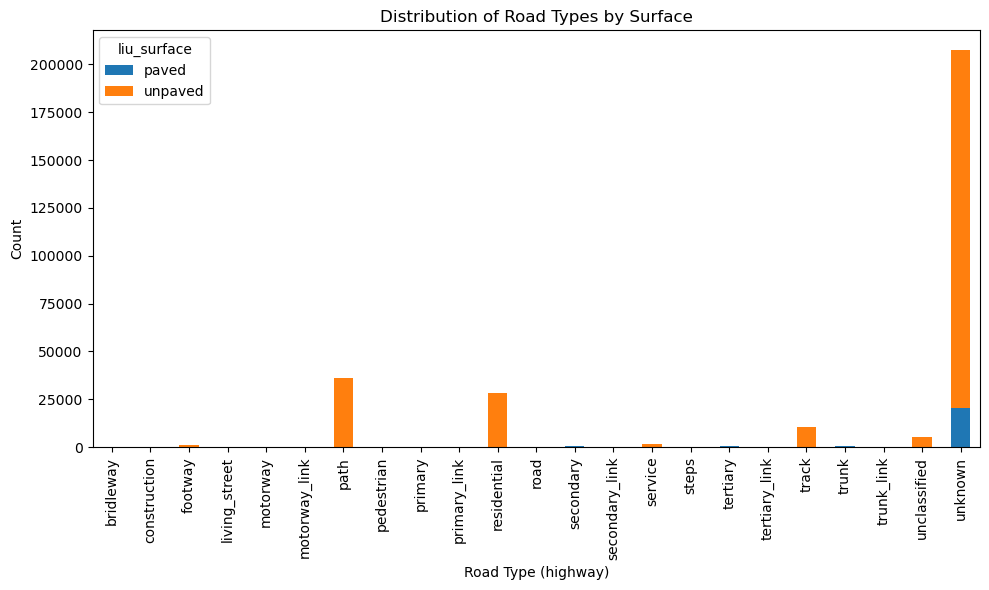

In [ ]:
# data inspection: check the distribution of road types and surfaces in the final cleaned dataset
# plot a stack bar chart of the counts of each road type (highway) grouped by surface type (liu_surface)
surface_counts = loaded_gdf.groupby(["highway", "liu_surface"]).size().unstack(fill_value=0)
surface_counts.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Distribution of Road Types by Surface")
plt.xlabel("Road Type (highway)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# I want to debug by creating a table in which the rows are highway classes and the columns are surface types, with the values being the counts of each combination
debug_table = loaded_gdf.groupby(["highway", "liu_surface"]).size().unstack(fill_value=0)
print(debug_table)

liu_surface     paved  unpaved
highway                       
bridleway           0       34
construction        0       90
footway             0      992
living_street       0      203
motorway           10        0
motorway_link       7        0
path                0    36247
pedestrian          0       62
primary           241        0
primary_link       13        0
residential         0    28034
road                0        5
secondary         372        0
secondary_link      3        0
service             0     1484
steps               0      137
tertiary          659        0
tertiary_link       3        0
track               0    10391
trunk             393        0
trunk_link          8        0
unclassified        0     5232
unknown         20210   187241
